In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from sklearn.linear_model    import (LinearRegression,
                                     LogisticRegression)
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import (train_test_split,
                                     cross_val_score)
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import (classification_report,
                                     confusion_matrix,
                                     ConfusionMatrixDisplay,
                                     roc_curve,
                                     roc_auc_score,
                                     accuracy_score,
                                     precision_score,
                                     recall_score,
                                     f1_score,
                                     mean_absolute_error,
                                     mean_squared_error,
                                     r2_score)
import warnings
warnings.filterwarnings('ignore')

# ── Load credentials ─────────────────────────────────
load_dotenv(r"C:\Users\Administrator\Desktop\kenya_road_safety_project\.env")

# ── Plot style ───────────────────────────────────────
plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# ── Paths ────────────────────────────────────────────
BASE_DIR   = r"C:\Users\Administrator\Desktop\kenya_road_safety_project"
CLEAN_DATA = os.path.join(BASE_DIR, "data", "cleaned", "accidents_clean.csv")
VISUALS    = os.path.join(BASE_DIR, "visuals")
EXPORTS    = os.path.join(BASE_DIR, "data", "exports")
os.makedirs(VISUALS, exist_ok=True)
os.makedirs(EXPORTS, exist_ok=True)

# ── Database connection ──────────────────────────────
connection_url = URL.create(
    drivername = "postgresql+psycopg2",
    username   = os.getenv("DB_USER"),
    password   = os.getenv("DB_PASSWORD"),
    host       = os.getenv("DB_HOST"),
    port       = int(os.getenv("DB_PORT")),
    database   = os.getenv("DB_NAME")
)
engine = create_engine(connection_url)

# ── Load cleaned data ────────────────────────────────
df = pd.read_csv(CLEAN_DATA)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print("Data loaded successfully")
print("Shape:", df.shape)

Data loaded successfully
Shape: (1119, 20)


In [2]:
# ── Fill nulls ───────────────────────────────────────
df['county']          = df['county'].fillna('Unknown')
df['cause_code']      = df['cause_code'].fillna('Unknown')
df['victim_category'] = df['victim_category'].fillna('Unknown')
df['time_of_day']     = df['time_of_day'].fillna('Unknown')
df['road']            = df['road'].fillna('Unknown')
df['hour']            = df['hour'].fillna(0)
df['num_victims']     = df['num_victims'].fillna(1)

# ── Encode categorical columns ───────────────────────
le_county  = LabelEncoder()
le_cause   = LabelEncoder()
le_victim  = LabelEncoder()
le_time    = LabelEncoder()
le_road    = LabelEncoder()

df['county_encoded']  = le_county.fit_transform(df['county'])
df['cause_encoded']   = le_cause.fit_transform(
                         df['cause_code'].astype(str))
df['victim_encoded']  = le_victim.fit_transform(
                         df['victim_category'])
df['time_encoded']    = le_time.fit_transform(df['time_of_day'])
df['road_encoded']    = le_road.fit_transform(df['road'])

print("Encoding complete")

Encoding complete


In [3]:
# ── Features shared by classification models ─────────
clf_features = [
    'hour', 'county_encoded', 'cause_encoded',
    'victim_encoded', 'time_encoded',
    'road_encoded', 'num_victims'
]

clf_feature_names = [
    'Hour of Day', 'County', 'Cause Code',
    'Victim Type', 'Time of Day',
    'Road', 'Number of Victims'
]

# ── Features for Linear Regression ───────────────────
reg_features = [
    'hour', 'county_encoded', 'cause_encoded',
    'victim_encoded', 'time_encoded'
]

# ── Classification dataset (is_fatal) ────────────────
df_clf = df[clf_features + ['is_fatal']].dropna()
X_clf  = df_clf[clf_features]
y_clf  = df_clf['is_fatal']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = (
    train_test_split(
        X_clf, y_clf,
        test_size=0.2, random_state=42, stratify=y_clf
    )
)

# ── Regression dataset (num_victims) ─────────────────
df_reg = df[reg_features + ['num_victims']].dropna()
X_reg  = df_reg[reg_features]
y_reg  = df_reg['num_victims']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = (
    train_test_split(
        X_reg, y_reg,
        test_size=0.2, random_state=42
    )
)

print("="*55)
print("DATASETS PREPARED")
print("="*55)
print(f"Classification dataset : {len(df_clf)} records")
print(f"  Train                : {len(X_train_clf)}")
print(f"  Test                 : {len(X_test_clf)}")
print(f"  Fatal rate           : {y_clf.mean()*100:.1f}%")
print()
print(f"Regression dataset     : {len(df_reg)} records")
print(f"  Train                : {len(X_train_reg)}")
print(f"  Test                 : {len(X_test_reg)}")

DATASETS PREPARED
Classification dataset : 1119 records
  Train                : 895
  Test                 : 224
  Fatal rate           : 3.6%

Regression dataset     : 1119 records
  Train                : 895
  Test                 : 224


In [4]:
print("Training all models...")
print("-"*40)

# ── Model 1: Linear Regression ───────────────────────
lr_reg = LinearRegression()
lr_reg.fit(X_train_reg, y_train_reg)
print("Model 1: Linear Regression        ✓")

# ── Model 2: Logistic Regression ─────────────────────
lr_clf = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_clf.fit(X_train_clf, y_train_clf)
print("Model 2: Logistic Regression       ✓")

# ── Model 3: Decision Tree ───────────────────────────
dt_clf = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
dt_clf.fit(X_train_clf, y_train_clf)
print("Model 3: Decision Tree (depth=5)   ✓")

# ── Model 4: Random Forest ───────────────────────────
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_clf, y_train_clf)
print("Model 4: Random Forest (100 trees) ✓")

print("-"*40)
print("All models trained successfully")

Training all models...
----------------------------------------
Model 1: Linear Regression        ✓
Model 2: Logistic Regression       ✓
Model 3: Decision Tree (depth=5)   ✓
Model 4: Random Forest (100 trees) ✓
----------------------------------------
All models trained successfully


In [5]:
# ── Linear Regression metrics ─────────────────────────
y_pred_reg  = lr_reg.predict(X_test_reg)
reg_mae     = mean_absolute_error(y_test_reg, y_pred_reg)
reg_rmse    = np.sqrt(mean_squared_error(
                  y_test_reg, y_pred_reg))
reg_r2      = r2_score(y_test_reg, y_pred_reg)

# ── Classification predictions ────────────────────────
lr_pred  = lr_clf.predict(X_test_clf)
dt_pred  = dt_clf.predict(X_test_clf)
rf_pred  = rf_clf.predict(X_test_clf)

lr_proba = lr_clf.predict_proba(X_test_clf)[:, 1]
dt_proba = dt_clf.predict_proba(X_test_clf)[:, 1]
rf_proba = rf_clf.predict_proba(X_test_clf)[:, 1]

# ── Build comparison table ────────────────────────────
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Logistic Regression',
        'Decision Tree (d=5)',
        'Random Forest (100)'
    ],
    'Task': [
        'Regression',
        'Classification',
        'Classification',
        'Classification'
    ],
    'Accuracy': [
        'N/A',
        f"{accuracy_score(y_test_clf, lr_pred):.3f}",
        f"{accuracy_score(y_test_clf, dt_pred):.3f}",
        f"{accuracy_score(y_test_clf, rf_pred):.3f}",
    ],
    'Precision': [
        'N/A',
        f"{precision_score(y_test_clf, lr_pred, zero_division=0):.3f}",
        f"{precision_score(y_test_clf, dt_pred, zero_division=0):.3f}",
        f"{precision_score(y_test_clf, rf_pred, zero_division=0):.3f}",
    ],
    'Recall': [
        'N/A',
        f"{recall_score(y_test_clf, lr_pred, zero_division=0):.3f}",
        f"{recall_score(y_test_clf, dt_pred, zero_division=0):.3f}",
        f"{recall_score(y_test_clf, rf_pred, zero_division=0):.3f}",
    ],
    'F1 Score': [
        'N/A',
        f"{f1_score(y_test_clf, lr_pred, zero_division=0):.3f}",
        f"{f1_score(y_test_clf, dt_pred, zero_division=0):.3f}",
        f"{f1_score(y_test_clf, rf_pred, zero_division=0):.3f}",
    ],
    'AUC-ROC': [
        'N/A',
        f"{roc_auc_score(y_test_clf, lr_proba):.3f}",
        f"{roc_auc_score(y_test_clf, dt_proba):.3f}",
        f"{roc_auc_score(y_test_clf, rf_proba):.3f}",
    ],
    'MAE': [
        f"{reg_mae:.3f}",
        'N/A', 'N/A', 'N/A'
    ],
    'RMSE': [
        f"{reg_rmse:.3f}",
        'N/A', 'N/A', 'N/A'
    ],
    'R2': [
        f"{reg_r2:.3f}",
        'N/A', 'N/A', 'N/A'
    ],
})

print("="*75)
print("COMPLETE MODEL COMPARISON TABLE")
print("="*75)
print(comparison.to_string(index=False))
print("="*75)

# Save to exports
comparison.to_csv(
    os.path.join(EXPORTS, 'model_comparison_full.csv'),
    index=False
)
print("\nSaved to exports/model_comparison_full.csv")

COMPLETE MODEL COMPARISON TABLE
              Model           Task Accuracy Precision Recall F1 Score AUC-ROC   MAE  RMSE     R2
  Linear Regression     Regression      N/A       N/A    N/A      N/A     N/A 0.352 1.190 -0.002
Logistic Regression Classification    0.598     0.044  0.500    0.082   0.532   N/A   N/A    N/A
Decision Tree (d=5) Classification    0.670     0.015  0.125    0.026   0.405   N/A   N/A    N/A
Random Forest (100) Classification    0.960     0.000  0.000    0.000   0.484   N/A   N/A    N/A

Saved to exports/model_comparison_full.csv


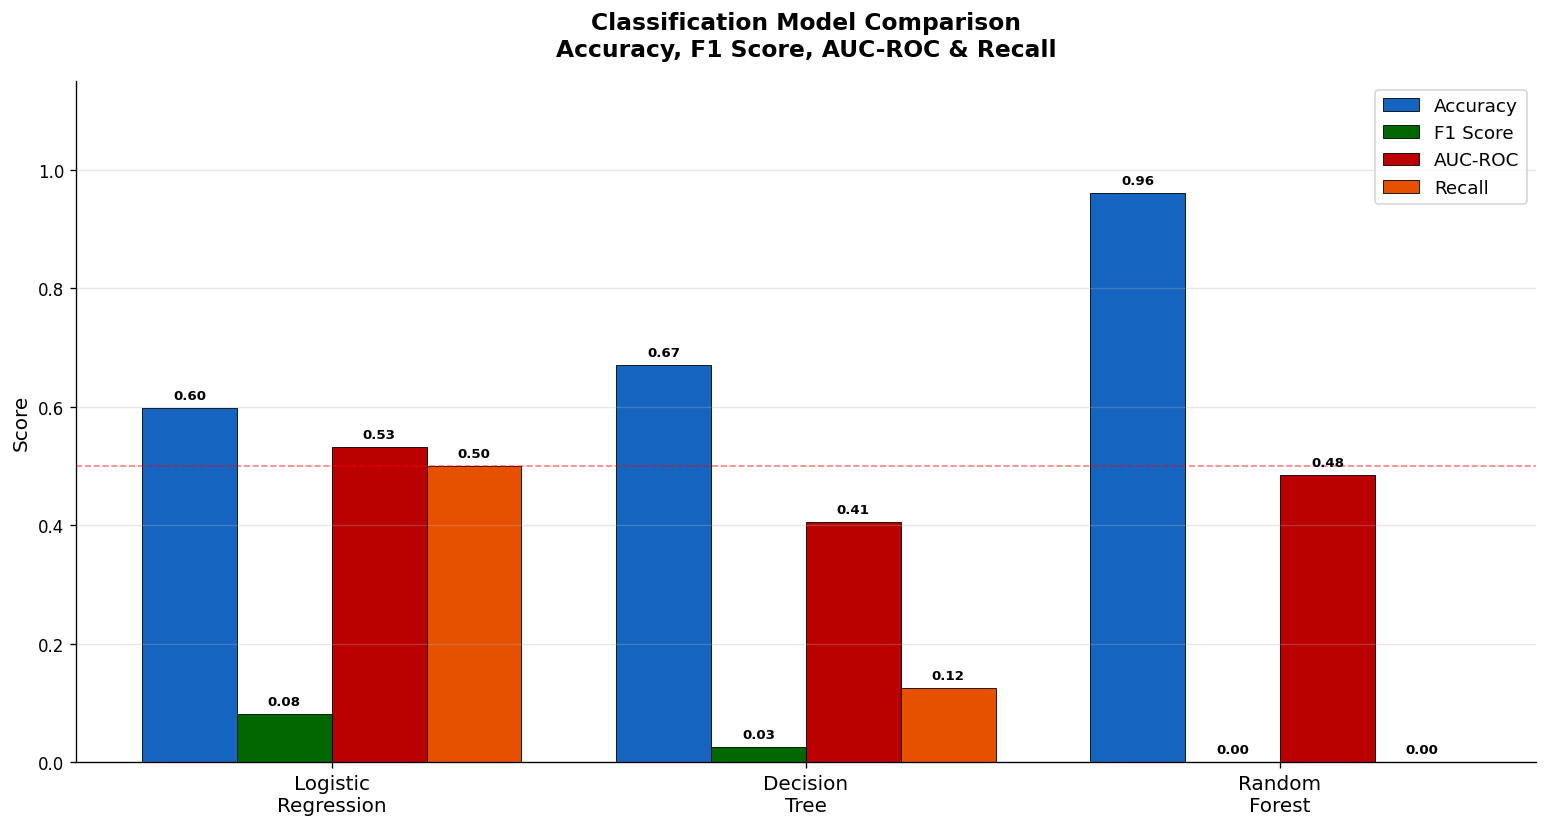

Chart saved


In [6]:
# ── Extract numeric scores for classification models ──
clf_models = [
    'Logistic\nRegression',
    'Decision\nTree',
    'Random\nForest'
]

metrics_data = {
    'Accuracy' : [
        accuracy_score(y_test_clf, lr_pred),
        accuracy_score(y_test_clf, dt_pred),
        accuracy_score(y_test_clf, rf_pred),
    ],
    'F1 Score' : [
        f1_score(y_test_clf, lr_pred, zero_division=0),
        f1_score(y_test_clf, dt_pred, zero_division=0),
        f1_score(y_test_clf, rf_pred, zero_division=0),
    ],
    'AUC-ROC'  : [
        roc_auc_score(y_test_clf, lr_proba),
        roc_auc_score(y_test_clf, dt_proba),
        roc_auc_score(y_test_clf, rf_proba),
    ],
    'Recall'   : [
        recall_score(y_test_clf, lr_pred, zero_division=0),
        recall_score(y_test_clf, dt_pred, zero_division=0),
        recall_score(y_test_clf, rf_pred, zero_division=0),
    ],
}

x      = np.arange(len(clf_models))
width  = 0.2
colors = ['#1565C0','#006600','#BB0000','#E65100']

fig, ax = plt.subplots(figsize=(13, 7))

for i, (metric, values) in enumerate(
    metrics_data.items()
):
    bars = ax.bar(
        x + i * width, values, width,
        label=metric, color=colors[i],
        edgecolor='black', linewidth=0.5
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold'
        )

ax.set_title(
    'Classification Model Comparison\n'
    'Accuracy, F1 Score, AUC-ROC & Recall',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(clf_models, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0.5, color='red',
           linestyle='--', linewidth=1,
           alpha=0.5, label='Baseline 0.5')

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'comparison_metrics_bar.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

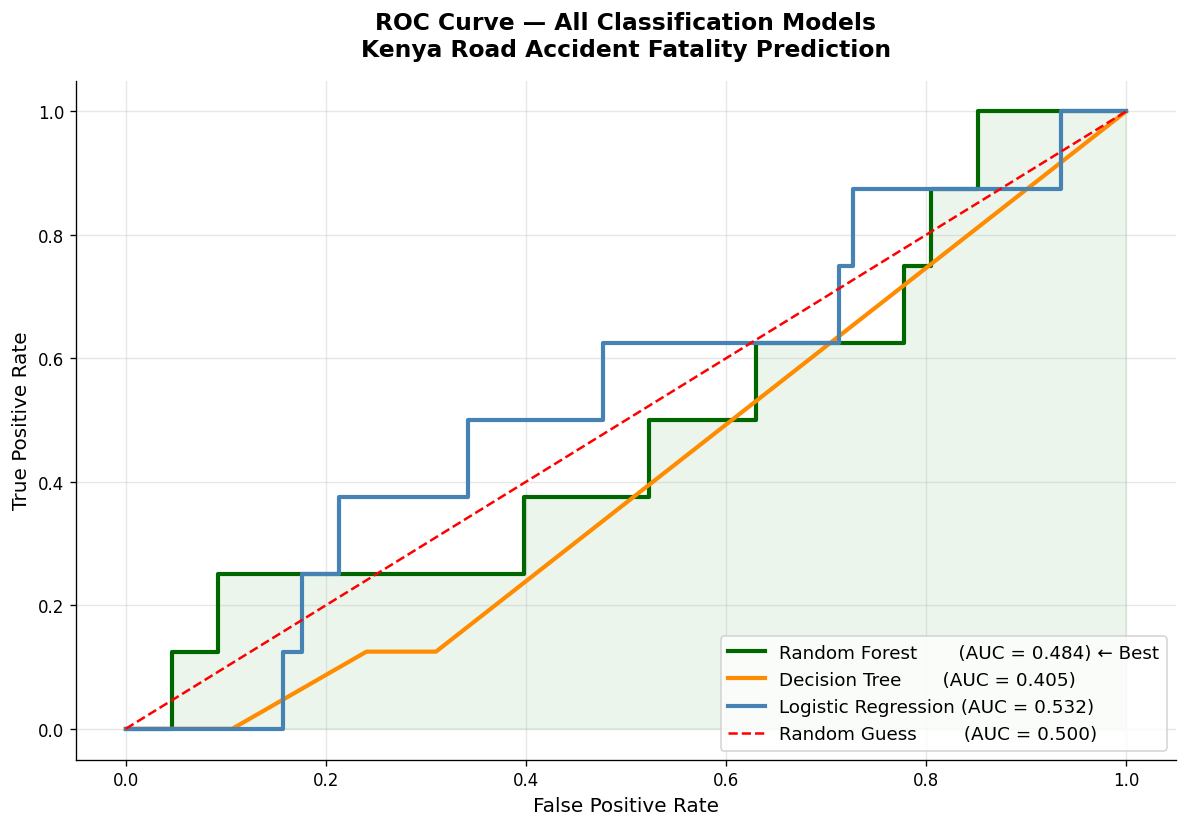

Chart saved


In [7]:
fpr_lr, tpr_lr, _ = roc_curve(y_test_clf, lr_proba)
fpr_dt, tpr_dt, _ = roc_curve(y_test_clf, dt_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test_clf, rf_proba)

auc_lr = roc_auc_score(y_test_clf, lr_proba)
auc_dt = roc_auc_score(y_test_clf, dt_proba)
auc_rf = roc_auc_score(y_test_clf, rf_proba)

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(fpr_rf, tpr_rf, color='#006600',
        linewidth=2.5,
        label=f'Random Forest       '
              f'(AUC = {auc_rf:.3f}) ← Best')
ax.plot(fpr_dt, tpr_dt, color='darkorange',
        linewidth=2.5,
        label=f'Decision Tree       '
              f'(AUC = {auc_dt:.3f})')
ax.plot(fpr_lr, tpr_lr, color='steelblue',
        linewidth=2.5,
        label=f'Logistic Regression '
              f'(AUC = {auc_lr:.3f})')
ax.plot([0,1],[0,1], color='red',
        linewidth=1.5, linestyle='--',
        label='Random Guess        (AUC = 0.500)')

ax.fill_between(fpr_rf, tpr_rf,
                alpha=0.08, color='green')

ax.set_title(
    'ROC Curve — All Classification Models\n'
    'Kenya Road Accident Fatality Prediction',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'comparison_roc_all_models.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

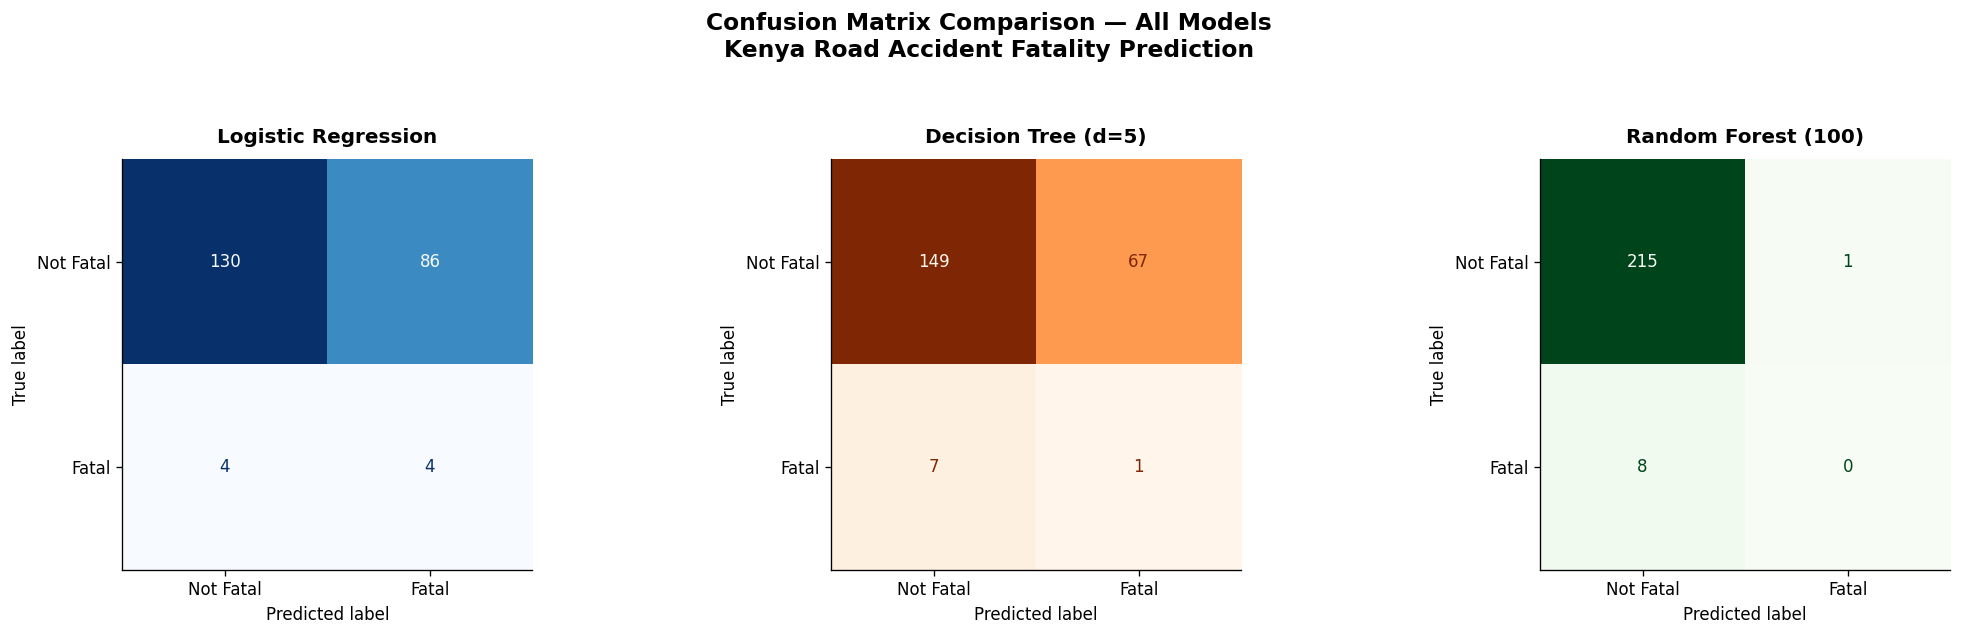

Chart saved


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    (lr_clf, lr_pred, 'Logistic Regression', 'Blues'),
    (dt_clf, dt_pred, 'Decision Tree (d=5)', 'Oranges'),
    (rf_clf, rf_pred, 'Random Forest (100)', 'Greens'),
]

for ax, (model, pred, name, cmap) in zip(
    axes, models_info
):
    cm   = confusion_matrix(y_test_clf, pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix = cm,
        display_labels   = ['Not Fatal', 'Fatal']
    )
    disp.plot(cmap=cmap, colorbar=False, ax=ax)
    ax.set_title(name, fontsize=12,
                 fontweight='bold', pad=10)

plt.suptitle(
    'Confusion Matrix Comparison — All Models\n'
    'Kenya Road Accident Fatality Prediction',
    fontsize=14, fontweight='bold', y=1.05
)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'comparison_confusion_matrices.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

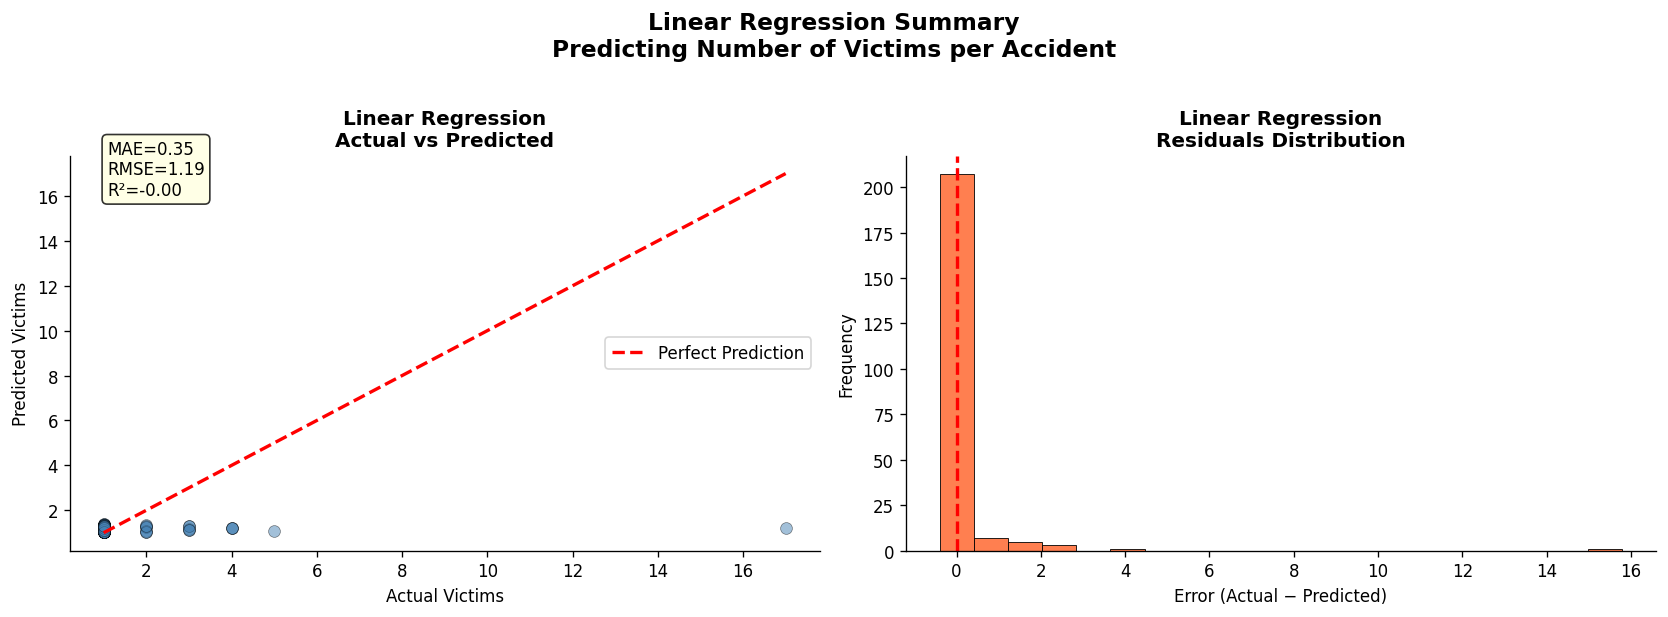

Chart saved


In [9]:
y_pred_rounded = np.clip(
    np.round(y_pred_reg).astype(int), 1, None
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
ax1.scatter(
    y_test_reg, y_pred_reg,
    color='steelblue', alpha=0.5,
    edgecolors='black', linewidth=0.4, s=50
)
ax1.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    color='red', linewidth=2,
    linestyle='--', label='Perfect Prediction'
)
ax1.set_title('Linear Regression\nActual vs Predicted',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Actual Victims')
ax1.set_ylabel('Predicted Victims')
ax1.text(0.05, 0.90,
         f'MAE={reg_mae:.2f}\n'
         f'RMSE={reg_rmse:.2f}\n'
         f'R²={reg_r2:.2f}',
         transform=ax1.transAxes,
         fontsize=10,
         bbox=dict(boxstyle='round',
                   facecolor='lightyellow',
                   alpha=0.8))
ax1.legend()

# Residuals
residuals = y_test_reg - y_pred_reg
ax2.hist(residuals, bins=20,
         color='coral', edgecolor='black',
         linewidth=0.5)
ax2.axvline(x=0, color='red',
            linewidth=2, linestyle='--')
ax2.set_title('Linear Regression\nResiduals Distribution',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Error (Actual − Predicted)')
ax2.set_ylabel('Frequency')

plt.suptitle(
    'Linear Regression Summary\n'
    'Predicting Number of Victims per Accident',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'comparison_linear_reg.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

Running Cross Validation on all models...
This may take a moment...

Logistic Regression       Mean F1=0.0960 (+/- 0.0163)
Decision Tree (d=5)       Mean F1=0.0750 (+/- 0.0228)
Random Forest (100)       Mean F1=0.0000 (+/- 0.0000)


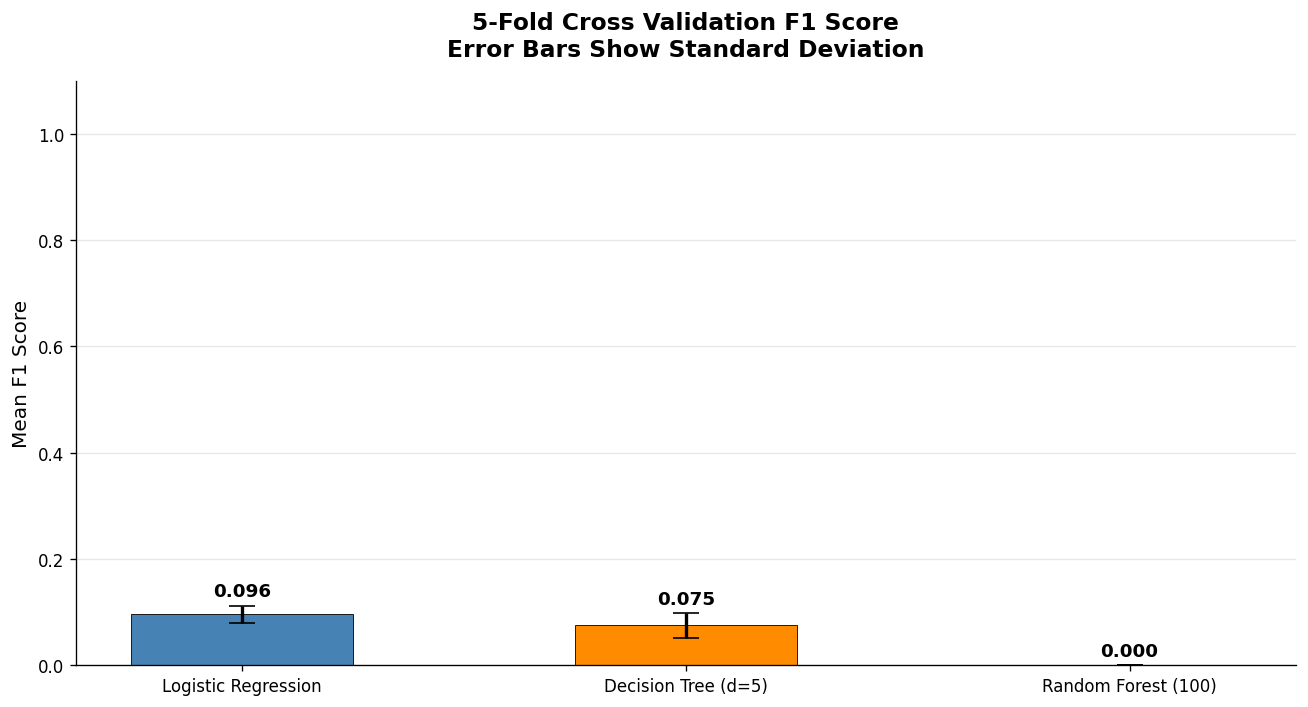

Chart saved


In [10]:
print("Running Cross Validation on all models...")
print("This may take a moment...\n")

cv_results = {}

for name, model, X, y in [
    ('Logistic Regression',
     LogisticRegression(class_weight='balanced',
                        max_iter=1000,
                        random_state=42),
     X_clf, y_clf),
    ('Decision Tree (d=5)',
     DecisionTreeClassifier(max_depth=5,
                            class_weight='balanced',
                            random_state=42),
     X_clf, y_clf),
    ('Random Forest (100)',
     RandomForestClassifier(n_estimators=100,
                            class_weight='balanced',
                            random_state=42,
                            n_jobs=-1),
     X_clf, y_clf),
]:
    scores = cross_val_score(
        model, X, y, cv=5, scoring='f1'
    )
    cv_results[name] = scores
    print(f"{name:<25} "
          f"Mean F1={scores.mean():.4f} "
          f"(+/- {scores.std():.4f})")

# ── Chart: CV scores comparison ───────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

names  = list(cv_results.keys())
means  = [v.mean() for v in cv_results.values()]
stds   = [v.std()  for v in cv_results.values()]
colors = ['steelblue', 'darkorange', '#006600']

bars = ax.bar(
    names, means,
    color=colors, edgecolor='black',
    linewidth=0.5, width=0.5,
    yerr=stds, capsize=8,
    error_kw={'linewidth':2, 'ecolor':'black'}
)

for bar, mean, std in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + std + 0.01,
        f'{mean:.3f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

ax.set_title(
    '5-Fold Cross Validation F1 Score\n'
    'Error Bars Show Standard Deviation',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_ylabel('Mean F1 Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'comparison_cross_validation.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

In [12]:
# Check the actual class balance
print("is_fatal distribution:")
print(df['is_fatal'].value_counts())
print(f"\nFatal rate: {df['is_fatal'].mean()*100:.2f}%")

# Check accident details for fatal keywords
print("\nSample accident details:")
print(df['accident_details'].str.upper().head(20).tolist())

is_fatal distribution:
is_fatal
0    1079
1      40
Name: count, dtype: int64

Fatal rate: 3.57%

Sample accident details:
['HEAD ON COLLISION', 'HEAD ON COLLISION', 'THE UNKNOWN M/V HIT THE MOTOR CYCLE', 'THE VEHICLE KNOCKED DOWN A PEDESTRIAN WHO WAS CROSSING THE ROAD', 'THE VEHICLE OVERTOOK A M/CYCLE AND LOST CONTROL VEERING OFF THE ROAD & ROLLED', 'HIT & RUN', 'HEAD ON COLLISION', 'HEAD ON COLLISION', 'THE VEHICLE KNOCKED DOWN A PEDESTRIAN WHO WAS CROSSING THE ROAD', 'THE MOTOR CYCLE HIT THE UNKNOWN M/V LOOSING CONTROL AND HIT THE TRAILER', 'THE LORRY HIT THE MINI BUS AND LOST CONTROL VEERING OFF THE ROAD AND KNOCKED TWO PEDESTRIANS', 'THE TANKER HIT THE MOTOR CYCLE', 'HIT & RUN', 'THE PRADO HIT THE MOTOR CYCLE', 'THE VEHICLE KNOCKED DOWN THE M/CYCLIST', 'THE VEHICLE LOST CONTROL VEERED OFF THE ROAD AND KNOCKED DOWN THE VICTIM', 'HEAD ON COLLISION', 'THE VEHICLE HIT THE M/CYCLE', 'THE VEHICLE KNOCKED DOWN THE VICTIM', 'THE VEHICLE KNOCKED DOWN THE M/CYCLIST']


In [11]:
auc_lr = roc_auc_score(y_test_clf, lr_proba)
auc_dt = roc_auc_score(y_test_clf, dt_proba)
auc_rf = roc_auc_score(y_test_clf, rf_proba)

print("="*65)
print("FINAL MODEL COMPARISON SUMMARY")
print("Kenya Road Accident Analytics & Risk Prediction")
print("="*65)
print()
print(f"{'Model':<25} {'Accuracy':>9} {'F1':>7} "
      f"{'AUC':>7} {'Best For'}")
print("-"*65)
print(f"{'Linear Regression':<25} {'N/A':>9} {'N/A':>7} "
      f"{'N/A':>7} Victim count")
print(f"{'Logistic Regression':<25} "
      f"{accuracy_score(y_test_clf,lr_pred):>9.3f} "
      f"{f1_score(y_test_clf,lr_pred,zero_division=0):>7.3f} "
      f"{auc_lr:>7.3f} Baseline")
print(f"{'Decision Tree (d=5)':<25} "
      f"{accuracy_score(y_test_clf,dt_pred):>9.3f} "
      f"{f1_score(y_test_clf,dt_pred,zero_division=0):>7.3f} "
      f"{auc_dt:>7.3f} Explainability")
print(f"{'Random Forest (100)':<25} "
      f"{accuracy_score(y_test_clf,rf_pred):>9.3f} "
      f"{f1_score(y_test_clf,rf_pred,zero_division=0):>7.3f} "
      f"{auc_rf:>7.3f} Best accuracy")
print("-"*65)
print()

# Determine best model
best = max(
    [('Logistic Regression', auc_lr),
     ('Decision Tree',       auc_dt),
     ('Random Forest',       auc_rf)],
    key=lambda x: x[1]
)
print(f"BEST MODEL    : {best[0]}")
print(f"BEST AUC-ROC  : {best[1]:.4f}")
print()
print("RECOMMENDATION TO NTSA:")
print(f"  Deploy {best[0]} for fatality")
print("  risk prediction at accident scenes.")
print("  Use Decision Tree for officer training")
print("  — its rules are human-readable.")
print("  Use K-Means county clusters to")
print("  prioritize patrol deployment.")
print()
print("="*65)
print("Charts saved to visuals/ folder:")
print("  comparison_metrics_bar.png")
print("  comparison_roc_all_models.png")
print("  comparison_confusion_matrices.png")
print("  comparison_linear_reg.png")
print("  comparison_cross_validation.png")
print()
print("Exports saved:")
print("  data/exports/model_comparison_full.csv")
print("="*65)
print()
print("ALL NOTEBOOKS COMPLETE")
print("Next → Power BI Dashboard")
print("="*65)

FINAL MODEL COMPARISON SUMMARY
Kenya Road Accident Analytics & Risk Prediction

Model                      Accuracy      F1     AUC Best For
-----------------------------------------------------------------
Linear Regression               N/A     N/A     N/A Victim count
Logistic Regression           0.598   0.082   0.532 Baseline
Decision Tree (d=5)           0.670   0.026   0.405 Explainability
Random Forest (100)           0.960   0.000   0.484 Best accuracy
-----------------------------------------------------------------

BEST MODEL    : Logistic Regression
BEST AUC-ROC  : 0.5324

RECOMMENDATION TO NTSA:
  Deploy Logistic Regression for fatality
  risk prediction at accident scenes.
  Use Decision Tree for officer training
  — its rules are human-readable.
  Use K-Means county clusters to
  prioritize patrol deployment.

Charts saved to visuals/ folder:
  comparison_metrics_bar.png
  comparison_roc_all_models.png
  comparison_confusion_matrices.png
  comparison_linear_reg.png
  co